In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Dict

from model_ranking import (
    load_h5,
    find_selftraining_pred_paths,
    identify_transfer,
    get_output_paths,
    get_ckpt_eval_scores,
    find_batchnorm_pred_path,
)

from pytorch3dunet.unet3d.config import (
    load_config_direct #pyright: ignore[reportUnknownVariableType]
)

INFO: P [MainThread] 2025-09-16 17:38:13,568 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
approach_mapping = {
    "DO": "feature_perturbation",
    "def": "default_selftraining",
    "cfd": "confidence_threshold",
    "F1": "direct_eval",
    "torchem": "supervised_torchem",
    "_SF_": "supervised",
    "ST": "supervised_training",
}

In [3]:
models: Dict[str, List[str]] = {
    "HtoE": [
        "HtoE_def_Hm_model4_2",
        "HtoE_def_Hm_model_NA2",
        "HtoE_def_Hm_model_Res1",
        #"HtoE_def_Hm_model_Unetr2",
    ],
    "RtoE": [
        "RtoE_def_Rm_model4",
        "RtoE_def_Rm_model_NA2",
        "RtoE_def_Rm_model_Res1",
        #"RtoE_def_Rm_model_Unetr2",
    ],
    "VtoE": [
        "VtoE_def_V_model2",
        "VtoE_def_V_model_NA2",
        #"VtoE_def_V_model_NA2_2",
        "VtoE_def_V_model_Res1",
    ],
    "EtoH": [
        "EtoH_def_E_model5",
        "EtoH_def_E_model_NA2",
        "EtoH_def_E_model_Res1",
        #"EtoH_def_E_model_Unetr2",

    ],
    "RtoH": [
        "RtoH_def_Rm_model4",
        "RtoH_def_Rm_model_NA2",
        "RtoH_def_Rm_model_Res1",
        #"RtoH_def_Rm_model_Unetr2",
    ],
    "VtoH": [
        "VtoH_def_V_model2",
        "VtoH_def_V_model_NA2",
        "VtoH_def_V_model_Res1",
    ],
    "EtoR": [
        "EtoR_def_E_model5",
        "EtoR_def_E_model_NA2",
        "EtoR_def_E_model_Res1",
        #"EtoR_def_E_model_Unetr2",
    ],
    "HtoR": [
        "HtoR_def_Hm_model4",
        "HtoR_def_Hm_model_NA2",
        #"HtoR_def_Hm_model_NA2_2",
        "HtoR_def_Hm_model_Res1",
        #"HtoR_def_Hm_model_Unetr2",
    ],
    "VtoR": [
        "VtoR_def_V_model2",
        "VtoR_def_V_model_NA2",
        "VtoR_def_V_model_Res1",
    ],
    "EtoV": [
        "EtoV_def_E_model5",
        "EtoV_def_E_model_NA2",
        "EtoV_def_E_model_Res1",
        #"EtoV_def_E_model_Unetr2",
    ],
    "HtoV": [
        "HtoV_def_Hm_model4",
        "HtoV_def_Hm_model_NA2",
        "HtoV_def_Hm_model_Res1",
        #"HtoV_def_Hm_model_Unetr2",
    ],
    "RtoV": [
        "RtoV_def_Rm_model4",
        "RtoV_def_Rm_model_NA2",
        "RtoV_def_Rm_model_Res1",
        #"RtoV_def_Rm_model_Unetr2",
    ],
}

In [ ]:
adabn_models: Dict[str, List[str]] = {
    "HtoE": ["HmtoE_model4", "HmtoE_model_NA2","HmtoE_model_Res1"], # "HmtoE_model_Unetr2"],
    "RtoE": [
        "RmtoE_model4",
        "RmtoE_model_NA2",
        "RmtoE_model_Res1",
        #"RmtoE_model_Unetr2",
    ],
    "VtoE": [
        "VtoE_model2",
        "VtoE_model_NA2",
        "VtoE_model_Res1",
    ],
    "EtoH": [
        "EtoHm_model5",
        "EtoHm_model_NA2",
        "EtoHm_model_Res1",
        #"EtoHm_model_Unetr2",
    ],
    "RtoH": [
        "RmtoHm_model4",
        "RmtoHm_model_NA2",
        "RmtoHm_model_Res1",
        #"RmtoHm_model_Unetr2",
    ],
    "VtoH": [
        "VtoHm_model2",
        "VtoHm_model_NA2",
        "VtoHm_model_Res1",
    ],
    "EtoR": [
        "EtoRm_model5",
        "EtoRm_model_NA2",
        "EtoRm_model_Res1",
        #"EtoRm_model_Unetr2",
    ],
    "HtoR": [
        "HmtoRm_model4",
        "HmtoRm_model_NA2",
        "HmtoRm_model_Res1",
        #"HmtoRm_model_Unetr2",
    ],
    "VtoR": [
        "VtoRm_model2",
        "VtoRm_model_NA2",
        "VtoRm_model_Res1",
    ],
    "EtoV": [
        "EtoV_model5",
        "EtoV_model_NA2",
        "EtoV_model_Res1",
        #"EtoV_model_Unetr2",
    ],
    "HtoV": [
        "HmtoV_model4",
        "HmtoV_model_NA2",
        "HmtoV_model_Res1",
        # "HmtoV_model_Unetr2",
    ],
    "RtoV": [
        "RmtoV_model4",
        "RmtoV_model_NA2",
        "RmtoV_model_Res1",
        #"RmtoV_model_Unetr2",
    ],
}

In [5]:
adabn_base_path = Path("/g/kreshuk/talks/model_ranking_results/AdaptiveBatchNorm/Mitochondria/train_mode_stats")

Transfer: HtoE
Hello


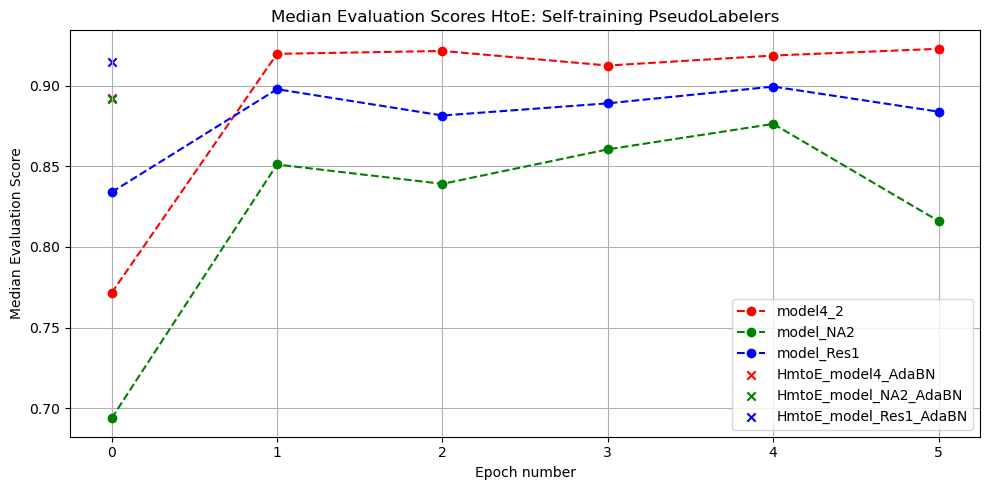

Transfer: RtoE
Hello


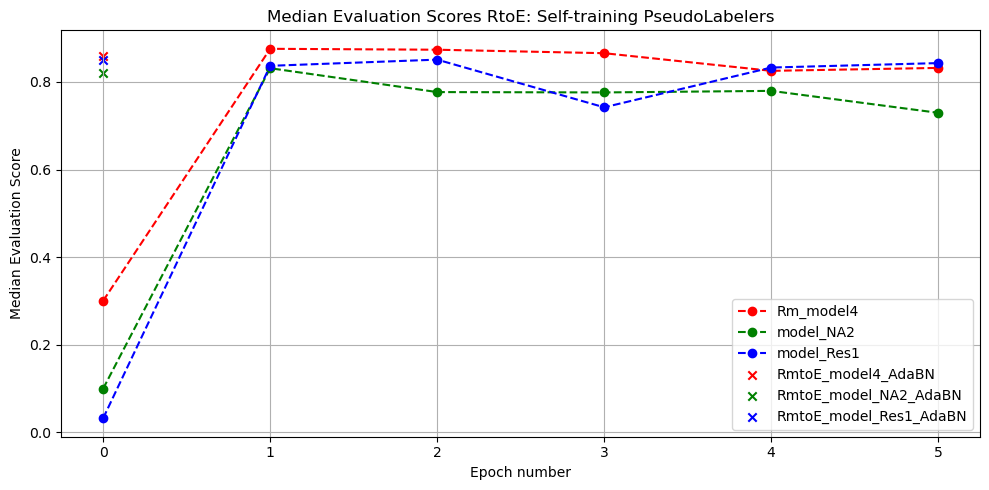

Transfer: VtoE
Hello


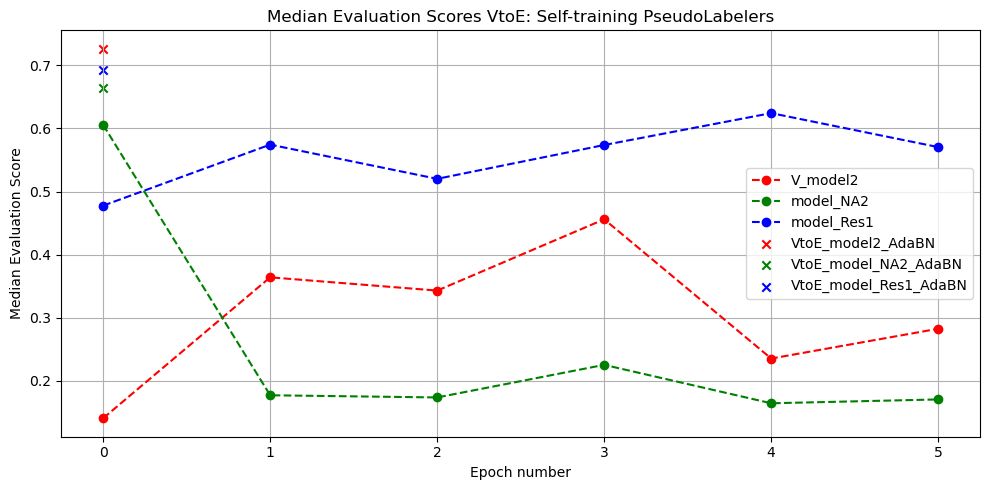

Transfer: EtoH
Hello


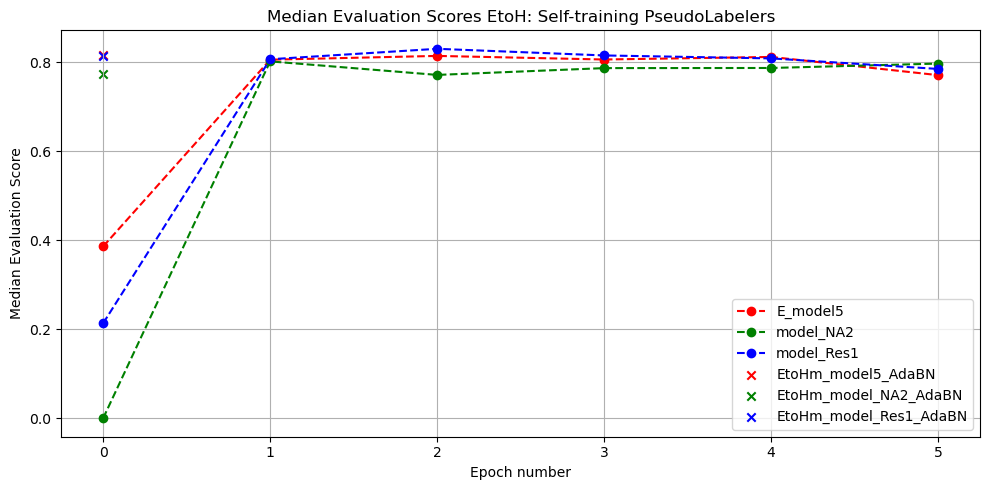

Transfer: RtoH
Hello


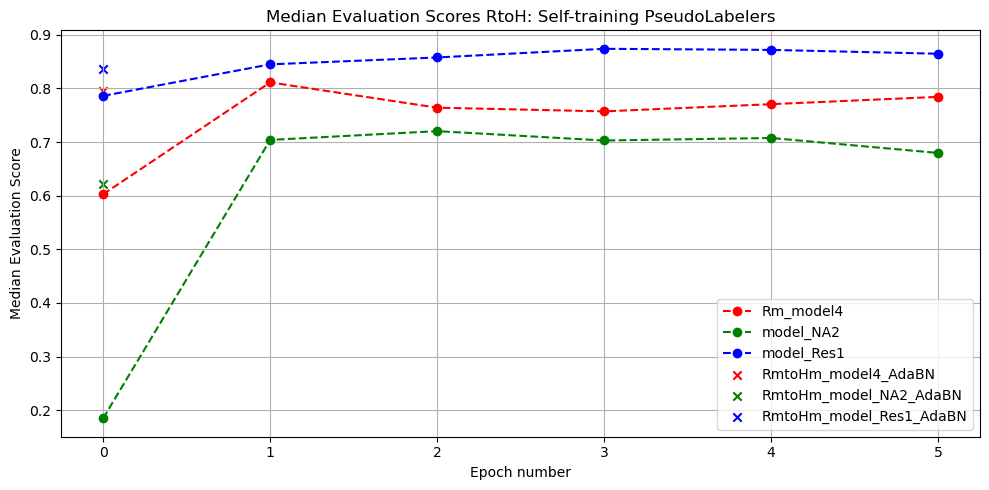

Transfer: VtoH
Hello


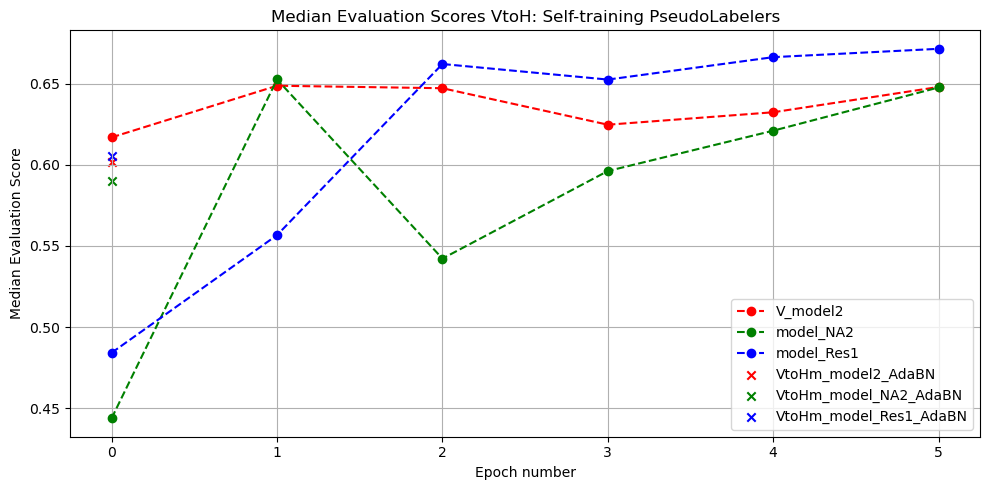

Transfer: EtoR
Hello


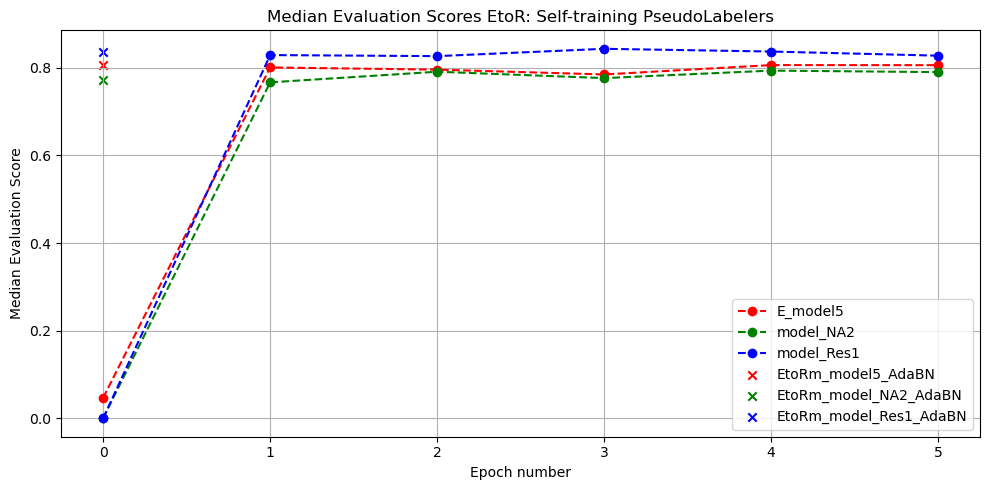

Transfer: HtoR
Hello


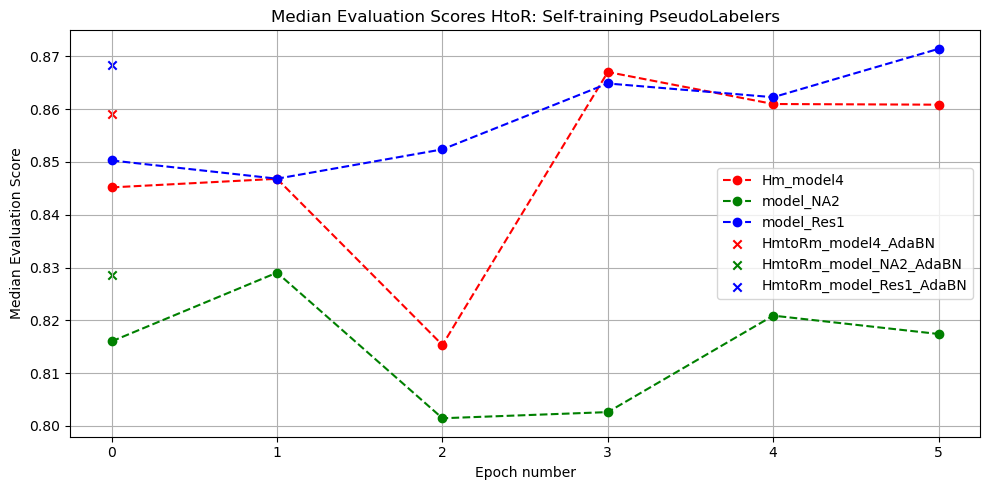

Transfer: VtoR
Hello


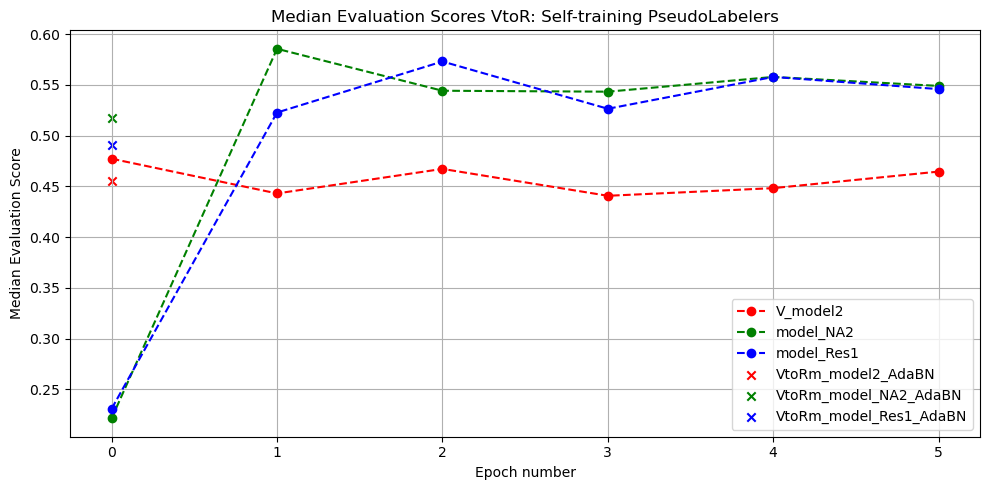

Transfer: EtoV
Hello


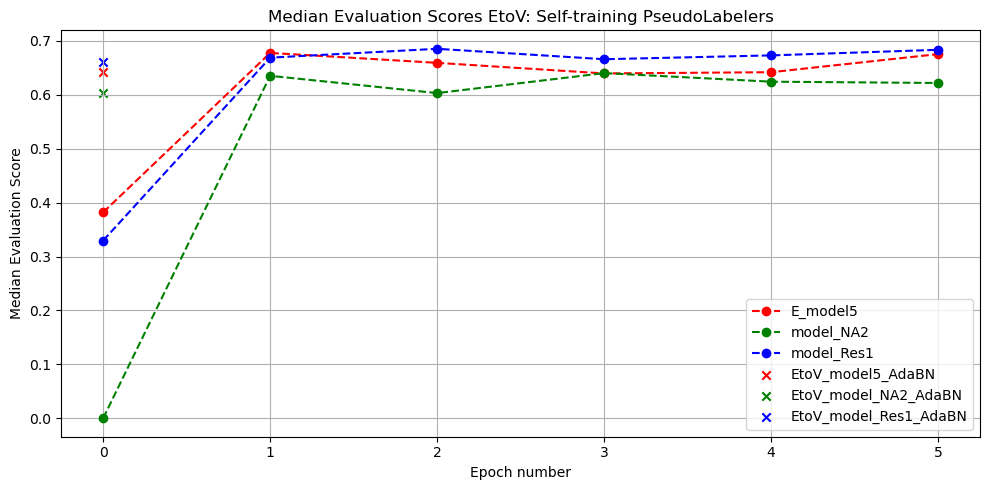

Transfer: HtoV
Hello


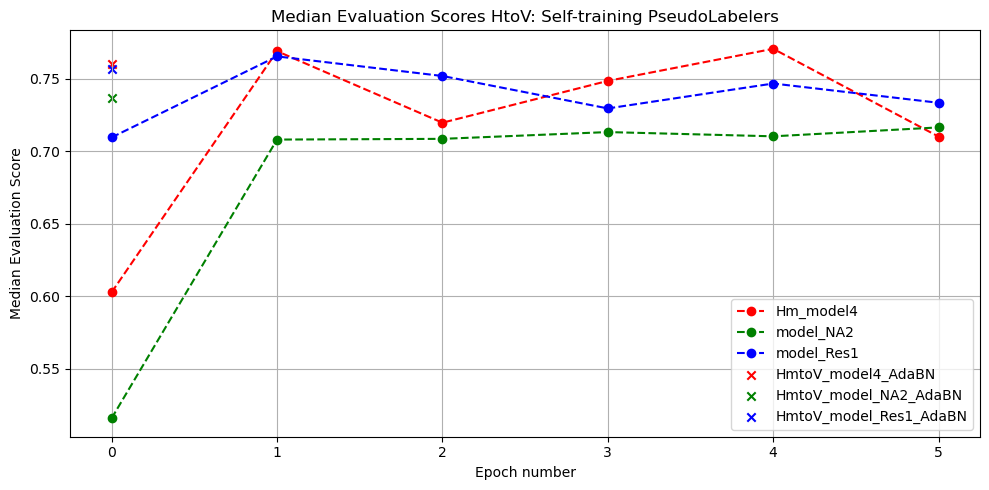

Transfer: RtoV
Hello


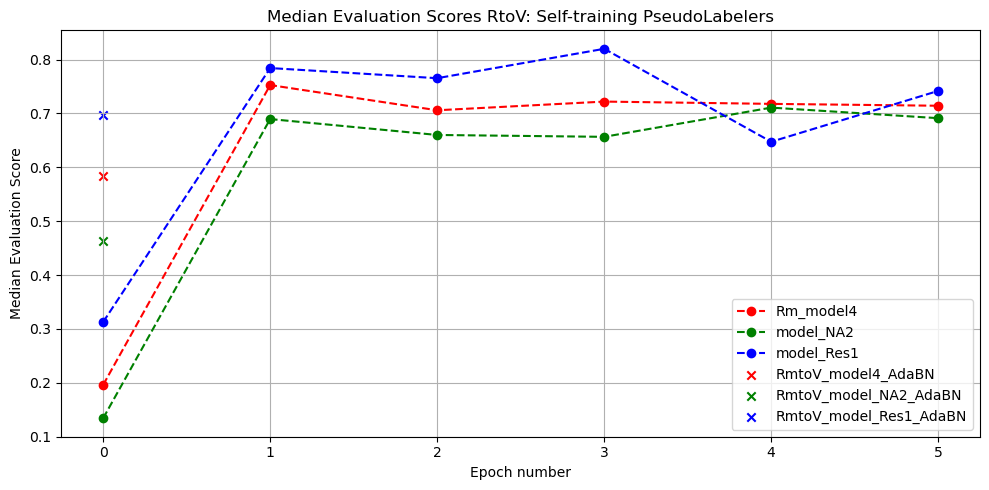

In [6]:

colours = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray']
best_epoch_per_transfer: Dict[str, Dict[str, int]] = {}
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    _ = plt.figure(figsize=(10,5))
    best_epochs_per_model: Dict[str, int] = {}
    for i, model_name in enumerate(model_list):
        if "SS" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/SemiSupervised-Finetuning/Mitochondria")
        elif "SF" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-Finetuning/Mitochondria")
        elif "ST" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-training/Mitochondria")
        else:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria")
        approach = None
        #label = None
        label = "_".join(model_name.split("_")[-2:])
        for key in approach_mapping:
            if key in model_name:
                approach = approach_mapping[key]

        assert approach is not None, f"Approach not found for model: {model_name}"
        assert label is not None, f"Label not found for model: {model_name}"

        pred_path = find_selftraining_pred_paths([model_name], approach=approach, base_path=base_path)[0]

        yaml_paths = list((pred_path.parent.parent / "checkpoints" / model_name).glob("*.yaml"))
        
        assert len(yaml_paths) == 1, f"Expected one YAML file for {model_name}, found {len(yaml_paths)}"
        yaml_path = yaml_paths[0]
        
        base_model_name = Path(load_config_direct(yaml_path)[0]["training"]["model_cfg"]["source_checkpoint"]).parent.stem
        
        transfer_name = identify_transfer(pred_path)
        assert transfer_name is not None, f"Transfer section not found in path: {pred_path}"
        target = transfer_name.split("_")[2]

        paths = get_output_paths(
            transfer_name.split("_")[0],
            transfer_name.split("_")[2],
            {"none": []}, 
            [None], 
            base_model_name, 
            output="predictions", 
            result_folder ="P_full", 
            approach="consistency",
            base_dir_path="/scratch/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(paths) == 1, f"Expected one path for {transfer_name} {base_model_name}, found {len(paths)}"
        direct_pred_path = list(Path(paths[0]).glob("*.h5"))
        # remove metric_summary_paths
        direct_pred_path = [p for p in direct_pred_path if "metric_summary" not in str(p)]
        assert len(direct_pred_path) == 1, f"Expected one direct prediction path for {transfer_name} {base_model_name}, found {len(direct_pred_path)}"

        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")
        eval_direct_median = np.median(eval_score_direct, axis=0)

        if "_SF_" in model_name:
            epoch_ids = list(range(1, 21, 2))
            #epoch_ids = list(range(1, 5, 2))
            #epoch_ids = list(range(2, 6, 2))
        else:
            #epoch_ids = list(range(2, 22, 2))
            #epoch_ids = list(range(1, 11, 1))
            epoch_ids = list(range(1, 6, 1))
            #epoch_ids = list(range(2, 6, 2))


        mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, epoch_ids)
        median_eval_scores.insert(0, eval_direct_median[1])
        #epochs = list(range(0, 22, 2))
        # epochs = list(range(0, 11, 1))
        epochs = list(range(0, 6, 1))
        #epochs = list(range(0, 6, 2))
        #epochs = epoch_ids.copy()
        #epochs.insert(0,0)  # Include the direct evaluation at epoch 0

        best_epoch_id = median_eval_scores.index(max(median_eval_scores))
        best_epochs_per_model[model_name] = best_epoch_id
        
        _ = plt.plot(epochs, median_eval_scores, marker='o', linestyle='--', color=colours[i], label=label)

    print("Hello")
    adabn_models_list = adabn_models.get(transfer, [])
    for i, model_name in enumerate(adabn_models_list):
        pred_path = find_batchnorm_pred_path(model_name, adabn_base_path, perturbation="none", return_summary=True)
        median_eval_score_adjusted = load_h5(pred_path, "F1_eval_median")[1]
        _ = plt.scatter([0], [median_eval_score_adjusted], marker='x', color=colours[i], label=model_name+"_AdaBN")


    best_epoch_per_transfer[transfer] = best_epochs_per_model

    _ =plt.title(f'Median Evaluation Scores {transfer}: Self-training PseudoLabelers')
    _ =plt.xlabel('Epoch number')
    _ =plt.ylabel(f'Median Evaluation Score')
    _ = plt.xticks(epochs)
    _ = plt.legend()
    plt.grid()
    plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
    plt.show()
